# Trabajo Práctico 1: Búsqueda y Optimización

## Búsqueda Global

Un almacén tiene distribuidos 48 productos en 6 estanterías de 8 productos cada uno en una distribución como la que se puede observar en la imagen. Además, el almacén cuenta con una zona de carga señalizada como "C" en el diagrama:


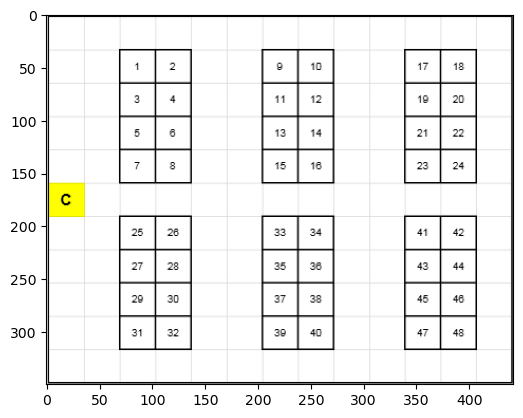

In [1]:
from skimage import io
import matplotlib.pyplot as plt

image = io.imread("https://drive.google.com/uc?export=view&id=1uXv0hJ7gNnpY_uErkTR-bcAlmq6VtbRV")
plt.imshow(image)
plt.show()

Programe el agente que usará el montacargas para navegar en el almacén usando un algoritmo A*. Tenga en cuenta las siguientes indicaciones:

* El agente solo puede moverse en los pasillos no ocupados por estantes

* El agente debe recibir como consigna la estantería a la que se desea mover el montacargas. Como la casilla numerada que reciba como consigna no es accesible, el agente debe detenerse en la casilla **horizontalmente adyacente** a la que tenga acceso

* El agente puede o no recibir una consigna de casilla inicial desde comenzar a navegar. En caso de que no se proporcione el dato, asuma que el movimiento se inicia en la estación de carga

* El costo de movimiento es uniforme. La heurística utilizada debe determinarla usted

Buscando ruta óptima hacia el estante 47.
Ruta óptima encontrada: [(10, 0), (10, 1), (10, 2), (10, 3), (10, 4), (10, 5), (10, 6), (10, 7), (10, 8), (9, 8), (9, 9)]
Costo de la ruta (pasos): 10


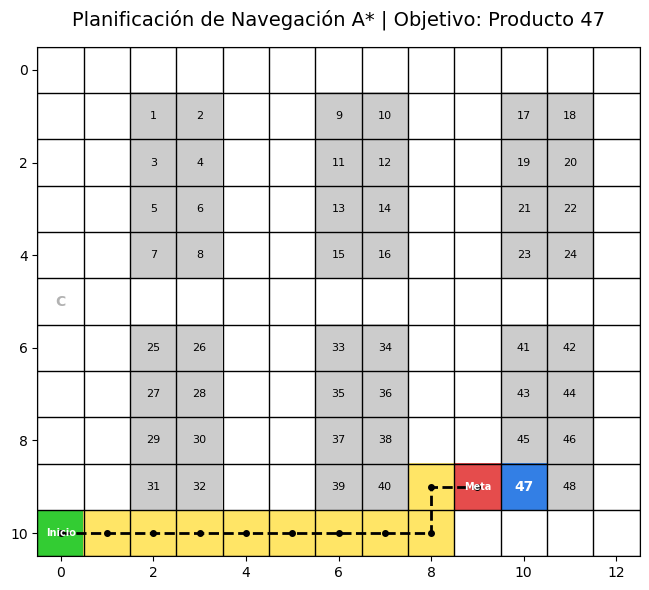

In [1]:
import heapq # Para importar la libreria de python mas completa, y utilizar heapq.heappop(), heapq.heappush()
import matplotlib.pyplot as plt
import numpy as np
    
"""
Almacena la posicion actual y su padre, hace desempate y no vuelve a pasar por misma posicion
"""
class Nodo:
    
    def __init__(self, posicion, padre=None):
        self.posicion = posicion  # (fila, col)
        self.padre = padre        # Para reconstruir la ruta al final
        self.g = 0                # Costo desde el inicio
        self.h = 0                # Valor de la heuristica
        self.f = 0                # Costo total f(n) = g(n) + h(n)

    """ Si los costos totales son iguales, se toma el de menor heuristica """
    def __lt__(self, otro):
        
        if self.f == otro.f:
            return self.h < otro.h
        
        return self.f < otro.f

    """ Para que el algoritmo no vuelva a una posicion anterior y entre en bucle """
    def __eq__(self, otro):
        return self.posicion == otro.posicion

"""
Almacena datos iniciales, busca posiciones,  
"""
class AgenteAlmacen:
    
    def __init__(self, mapa_almacen):
        self.mapa = mapa_almacen # Carga las posiciones del almacen
        self.filas = len(mapa_almacen)
        self.columnas = len(mapa_almacen[0])
        self.estacion_carga = self._encontrar_casilla('C')

    """Busca y retorna la (fila, col) de un valor específico en la matriz """
    def _encontrar_casilla(self, valor):
        
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.mapa[i][j] == valor:
                    return (i, j)
        return None
    
    """
    Determina las posiciones adyacentes posibles de todas las estanterias
    """
    def _obtener_metas_adyacentes(self, posicion_estante):
        
        fila, col = posicion_estante
        metas_validas = []
        
        movimientos_horizontales = [(0, -1), (0, 1)]
        
        for df, dc in movimientos_horizontales:
            n_fila, n_col = fila + df, col + dc
            # Si está dentro de los límites y es un pasillo libre (0) o la estación ('C'), se guarda
            if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                    metas_validas.append((n_fila, n_col))
                    
        return metas_validas
    
    """
    Calcula la distancia de Manhattan (ya que para este CASO esta funcion nunca
    sobreestima la distancia real) hacia la meta, donde si hay mas de una meta 
    posible se toma la de menor distancia
    """
    def heuristica_manhattan(self, pos_actual, metas_posibles):
        
        distancias = []
        for meta in metas_posibles:
            dist = abs(pos_actual[0] - meta[0]) + abs(pos_actual[1] - meta[1])
            distancias.append(dist)
        return min(distancias)
    
    """
    Implementación del Algoritmo A* (Búsqueda Global Heurística).
    """
    def buscar_ruta(self, id_estanteria, inicio=None):

        # Si no se provee inicio, se asume la estación de carga "C"
        if inicio is None:
            inicio = self.estacion_carga

        # 1. Identifica la posición del producto en la estanteria
        pos_estante = self._encontrar_casilla(id_estanteria)
        if pos_estante is None:
            raise ValueError(f"La estantería {id_estanteria} no existe en el mapa.")

        # 2. Determina las casillas meta posibles
        metas = self._obtener_metas_adyacentes(pos_estante)
        if not metas:
            raise ValueError("No hay casillas adyacentes accesibles para esta estantería.")

        # Inicializar listas Abierta (nodos por evaluar) y Cerrada (nodos evaluados)
        nodo_inicio = Nodo(inicio)
        lista_abierta = []
        heapq.heappush(lista_abierta, nodo_inicio)
        lista_cerrada = set()

        # Definimos los movimientos permitidos (Arriba, Abajo, Izquierda, Derecha)
        movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        # Algoritmo A*
        while len(lista_abierta) > 0:
            # Extraer el nodo con el menor f(n)
            nodo_actual = heapq.heappop(lista_abierta)

            # Prueba de llegada a meta
            if nodo_actual.posicion in metas:
                ruta = []
                actual = nodo_actual
                while actual is not None:
                    ruta.append(actual.posicion)
                    actual = actual.padre
                return ruta[::-1]  # Retornar la ruta invertida desde inicio hasta meta)

            # Añadimos a los visitados
            lista_cerrada.add(nodo_actual.posicion)

            # Expandimos el nodo
            for mov in movimientos:
                n_fila = nodo_actual.posicion[0] + mov[0]
                n_col = nodo_actual.posicion[1] + mov[1]
                pos_sucesora = (n_fila, n_col)

                # Chequeamos límites del mapa y obstaculos
                if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                    # Solo nos movemos por pasillos (0) o la estación ('C')
                    if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                        
                        # Evitamos que entre a analizar un nodo anteriormente evaluado
                        if pos_sucesora in lista_cerrada:
                            continue # No termina la iteracion, solo la saltea

                        # Crea un nodo sucesor
                        sucesor = Nodo(pos_sucesora, nodo_actual)
                        sucesor.g = nodo_actual.g + 1 # Costo uniforme
                        sucesor.h = self.heuristica_manhattan(sucesor.posicion, metas)
                        sucesor.f = sucesor.g + sucesor.h

                        # Verificamos si el nodo actual ya está en la lista abierta con menor costo total
                        en_abierta_con_menor_costo = False
                        for nodo_abierto in lista_abierta:
                            if sucesor == nodo_abierto and sucesor.g >= nodo_abierto.g:
                                en_abierta_con_menor_costo = True
                                break
                        
                        if not en_abierta_con_menor_costo:
                            heapq.heappush(lista_abierta, sucesor)

        return None # Falla: No se encontró ruta


def visualizar_almacen_y_ruta(mapa_almacen, ruta, id_objetivo, metas, inicio):
    
    filas = len(mapa_almacen)
    columnas = len(mapa_almacen[0])
    
    imagen = np.ones((filas, columnas, 3))
    
    color_pasillo = [1.0, 1.0, 1.0]     # Blanco
    color_estante = [0.8, 0.8, 0.8]     # Gris claro
    color_inicio = [0.2, 0.8, 0.2]      # Verde
    color_meta = [0.9, 0.3, 0.3]        # Rojo
    color_objetivo = [0.2, 0.5, 0.9]    # Azul
    color_ruta = [1.0, 0.9, 0.4]        # Amarillo pastel
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i in range(filas):
        for j in range(columnas):
            celda = mapa_almacen[i][j]
            
            if celda == 0:
                imagen[i, j] = color_pasillo
                
            elif celda == 'C':
                imagen[i, j] = color_pasillo 
                ax.text(j, i, 'C', ha='center', va='center', color='black', fontweight='bold', alpha=0.3)
                
            else: 
                if celda == id_objetivo:
                    imagen[i, j] = color_objetivo
                    ax.text(j, i, str(celda), ha='center', va='center', color='white', fontweight='bold')
                else:
                    imagen[i, j] = color_estante
                    ax.text(j, i, str(celda), ha='center', va='center', color='black', fontsize=8)
    
    for m in metas:
        imagen[m[0], m[1]] = color_meta
        ax.text(m[1], m[0], 'Meta', ha='center', va='center', color='white', fontsize=7, fontweight='bold')
        
    imagen[inicio[0], inicio[1]] = color_inicio
    ax.text(inicio[1], inicio[0], 'Inicio', ha='center', va='center', color='white', fontsize=7, fontweight='bold')

    if ruta:
        for paso in ruta[1:-1]:
            imagen[paso[0], paso[1]] = color_ruta
            
        y_ruta = [p[0] for p in ruta]
        x_ruta = [p[1] for p in ruta]
        ax.plot(x_ruta, y_ruta, color='black', linewidth=2, linestyle='--', marker='.', markersize=8)

    ax.imshow(imagen)
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", size=0) # Ocultar las marcas del eje menor
    ax.set_title(f"Planificación de Navegación A* | Objetivo: Producto {id_objetivo}", fontsize=14, pad=15)
    
    plt.tight_layout() 
    plt.show()

#  0  = Pasillo transitable
# 'C' = Estacion de carga
# 1 al 48 = IDs de los productos en las estanterías

matriz_almacen = [
    # Pasillo superior
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    
    # Estanterías 1 y 2
    [ 0,   0,   1,   2,   0,   0,   9,  10,   0,   0,  17,  18,   0 ],
    [ 0,   0,   3,   4,   0,   0,  11,  12,   0,   0,  19,  20,   0 ],
    [ 0,   0,   5,   6,   0,   0,  13,  14,   0,   0,  21,  22,   0 ],
    [ 0,   0,   7,   8,   0,   0,  15,  16,   0,   0,  23,  24,   0 ],
    
    # Pasillo central
    [ 'C', 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    
    # Estanterías 3 y 4
    [ 0,   0,  25,  26,   0,   0,  33,  34,   0,   0,  41,  42,   0 ],
    [ 0,   0,  27,  28,   0,   0,  35,  36,   0,   0,  43,  44,   0 ],
    [ 0,   0,  29,  30,   0,   0,  37,  38,   0,   0,  45,  46,   0 ],
    [ 0,   0,  31,  32,   0,   0,  39,  40,   0,   0,  47,  48,   0 ],
    
    # Pasillo inferior
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ]
]

agente = AgenteAlmacen(matriz_almacen)

# Definimos coordenada actual, si queremos
coordenada_actual = (10, 0)

producto_objetivo = 47
ruta_encontrada = agente.buscar_ruta(producto_objetivo, inicio = coordenada_actual)

print(f"Buscando ruta óptima hacia el estante {producto_objetivo}.")
if ruta_encontrada:
    print(f"Ruta óptima encontrada: {ruta_encontrada}")
    print(f"Costo de la ruta (pasos): {len(ruta_encontrada) - 1}")
else:
    print("No se encontró una ruta factible.")

posicion_estante = agente._encontrar_casilla(producto_objetivo)
metas_posibles = agente._obtener_metas_adyacentes(posicion_estante)
if coordenada_actual is None:
    inicio_utilizado = agente.estacion_carga
else:
    inicio_utilizado = coordenada_actual

visualizar_almacen_y_ruta(matriz_almacen, ruta_encontrada, producto_objetivo, metas_posibles, inicio_utilizado)



--- CONFIGURACIÓN DEL SISTEMA MULTI-AGENTE A* ---
Nota: Para las coordenadas de inicio, use el formato fila,columna (ej: 10,0).
Si desea usar la estación de carga 'C', simplemente presione Enter.

>> PARÁMETROS MONTACARGAS 1:



>> PARÁMETROS MONTACARGAS 2:

Procesando planificador de rutas...
Ruta M1 planificada con éxito (14 pasos).
Ruta M2 planificada con éxito (9 pasos).

Desplegando entorno gráfico...


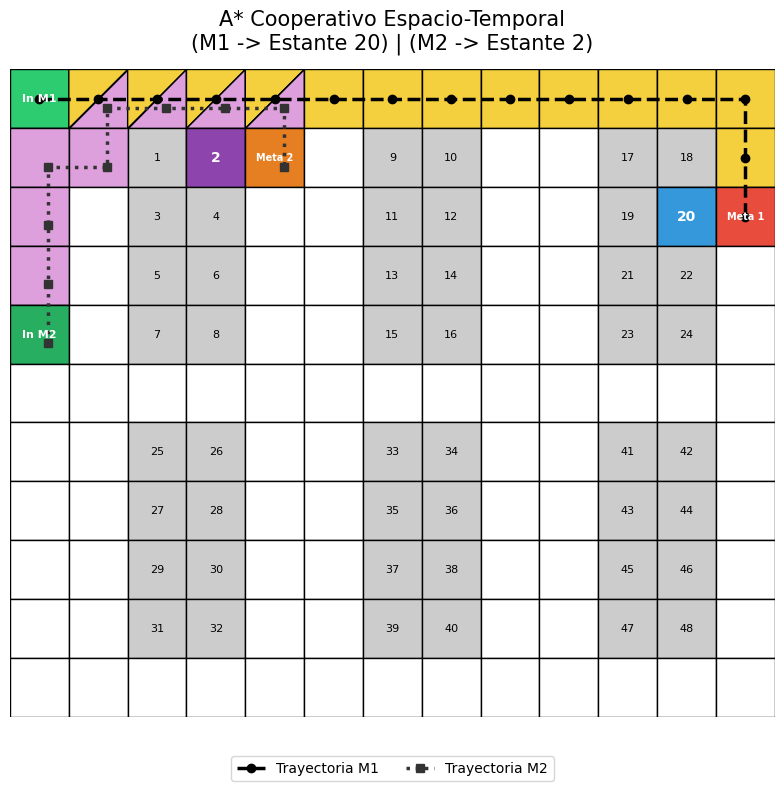

In [2]:
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

class Nodo:
    #Esta clase representa un estado en el espacio de busqueda Espacio-Temporal
    #Queda definido por una tupla tridimensional (coordenada x, coordenada y, tiempo)
    def __init__(self, posicion, padre=None, t=0):
        self.posicion = posicion  #Tupla (fila, columna)
        self.padre = padre        #Referencia al nodo padre
        self.g = 0                #Costo acumulado g(n)
        self.h = 0                #Heurística h(n)
        self.f = 0                #Costo total f(n) = g(n) + h(n)
        self.t = t                #Dimensión temporal

    def __lt__(self, otro):
        #Sobrecargamos el operador menor que
        #Para que la estructura de datos sepa como ordenar los nodos, siempre extraemos primero el nodo con el menor valor
        if self.f == otro.f:
            #Si dos nodos tienen el mismo valor, se implementa un desempate con el que este mas cerca de la meta
            return self.h < otro.h
        return self.f < otro.f

    def __eq__(self, otro):
        #Sobrecargamos el operador igual, permite que el agente pase por la misma casilla pero en distintos momentos
        return self.posicion == otro.posicion and self.t == otro.t


class AgenteAlmacen:
    #Agente racional encargado de navegar el almacén utilizando A* Cooperativo
    def __init__(self, mapa_almacen):
        self.mapa = mapa_almacen
        self.filas = len(mapa_almacen)
        self.columnas = len(mapa_almacen[0])
        self.estacion_carga = self._encontrar_casilla('C')

    def _encontrar_casilla(self, valor):
        #Escanea la matriz para encontrar las coordenadas espaciales de un valor especifico
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.mapa[i][j] == valor:
                    return (i, j)
        return None

    def _obtener_metas_adyacentes(self, posicion_estante):
        #Calcula las casillas objetivo validas
        fila, col = posicion_estante
        metas_validas = []
        #Solo adyacencia horizontal (Izquierda y Derecha)
        movimientos_horizontales = [(0, -1), (0, 1)]
        
        for df, dc in movimientos_horizontales:
            n_fila, n_col = fila + df, col + dc
            if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                    metas_validas.append((n_fila, n_col))
        return metas_validas

    def heuristica_manhattan(self, pos_actual, metas_posibles):
        #Funcion heuristica, Utiliza la distancia de Manhattan porque los movimientos son ortogonales
        
        distancias = []
        for meta in metas_posibles:
            dist = abs(pos_actual[0] - meta[0]) + abs(pos_actual[1] - meta[1])
            distancias.append(dist)
        return min(distancias)

    def _posicion_en_tiempo(self, ruta, t):
        #Calcula la posición de un agente en un instante t.
        #Si t excede la longitud de la ruta, asume que el agente está estacionado al final.

        if not ruta:
            return None
        if t < len(ruta):
            return ruta[t]
        return ruta[-1]

    def buscar_ruta(self, id_estanteria, inicio=None, ruta_otro_agente=None):


        if inicio is None:
            inicio = self.estacion_carga

        pos_estante = self._encontrar_casilla(id_estanteria)
        if pos_estante is None:
            raise ValueError(f"La estantería {id_estanteria} no existe en el mapa.")

        metas = self._obtener_metas_adyacentes(pos_estante)
        if not metas:
            raise ValueError("No hay casillas adyacentes accesibles para esta estantería.")

        nodo_inicio = Nodo(posicion=inicio, t=0)
        lista_abierta = []
        heapq.heappush(lista_abierta, nodo_inicio)
        
        #El conjunto cerrado almacena tuplas (posicion, tiempo)
        lista_cerrada = set()

        #Movimientos: Arriba, Abajo, Izquierda, Derecha, ESPERAR (0,0)
        movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1), (0, 0)]

        while len(lista_abierta) > 0:
            nodo_actual = heapq.heappop(lista_abierta)

            #Prueba de meta
            if nodo_actual.posicion in metas:
                ruta = []
                actual = nodo_actual
                while actual is not None:
                    ruta.append(actual.posicion)
                    actual = actual.padre
                return ruta[::-1]

            estado_actual = (nodo_actual.posicion, nodo_actual.t)
            lista_cerrada.add(estado_actual)

            for mov in movimientos:
                n_fila = nodo_actual.posicion[0] + mov[0]
                n_col = nodo_actual.posicion[1] + mov[1]
                pos_sucesora = (n_fila, n_col)
                t_sucesor = nodo_actual.t + 1

                #1. Restricciones del mapa estático
                if not (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                    continue
                if self.mapa[n_fila][n_col] != 0 and self.mapa[n_fila][n_col] != 'C':
                    continue

                estado_sucesor = (pos_sucesora, t_sucesor)
                if estado_sucesor in lista_cerrada:
                    continue

                #2. Restricciones dinámicas (Evasión del otro montacargas)
                if ruta_otro_agente:
                    pos_otro_futura = self._posicion_en_tiempo(ruta_otro_agente, t_sucesor)
                    pos_otro_actual = self._posicion_en_tiempo(ruta_otro_agente, nodo_actual.t)

                    # Colisión de Vértice / Estacionamiento
                    if pos_sucesora == pos_otro_futura:
                        continue 

                    # Colisión de Arista (Swapping)
                    if pos_sucesora == pos_otro_actual and nodo_actual.posicion == pos_otro_futura:
                        continue

                #3. Creación y evaluación del nodo sucesor
                sucesor = Nodo(posicion=pos_sucesora, padre=nodo_actual, t=t_sucesor)
                sucesor.g = nodo_actual.g + 1 
                sucesor.h = self.heuristica_manhattan(sucesor.posicion, metas)
                sucesor.f = sucesor.g + sucesor.h

                en_abierta_con_menor_costo = False
                for nodo_abierto in lista_abierta:
                    if sucesor == nodo_abierto and sucesor.g >= nodo_abierto.g:
                        en_abierta_con_menor_costo = True
                        break
                
                if not en_abierta_con_menor_costo:
                    heapq.heappush(lista_abierta, sucesor)

        return None


def visualizar_rutas_multiagente(mapa, ruta_m1, ruta_m2, obj_m1, obj_m2, metas_m1, metas_m2, inicio_m1, inicio_m2):
    """
    Renderiza el almacén y las rutas. Divide las celdas compartidas en dos triángulos
    para evitar superposición de colores.
    """
    filas = len(mapa)
    columnas = len(mapa[0])
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    c_pasillo = '#FFFFFF'
    c_estante = '#CCCCCC'
    
    # Colores Montacargas 1
    c_ruta_m1 = '#F4D03F' # Amarillo
    c_obj_m1 = '#3498DB'  # Azul
    c_meta_m1 = '#E74C3C' # Rojo
    c_inicio_m1 = '#2ECC71' # Verde
    
    # Colores Montacargas 2
    c_ruta_m2 = '#DDA0DD' # Ciruela
    c_obj_m2 = '#8E44AD'  # Púrpura
    c_meta_m2 = '#E67E22' # Naranja
    c_inicio_m2 = '#27AE60' # Verde oscuro
    
    set_ruta_m1 = set(ruta_m1[1:-1]) if ruta_m1 else set()
    set_ruta_m2 = set(ruta_m2[1:-1]) if ruta_m2 else set()
    
    for i in range(filas):
        for j in range(columnas):
            celda = mapa[i][j]
            x0, y0 = j - 0.5, i - 0.5 
            
            # Fondo base
            color_fondo = c_pasillo if celda == 0 or celda == 'C' else c_estante
            rect = patches.Rectangle((x0, y0), 1, 1, facecolor=color_fondo, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
            
            es_ruta1 = (i, j) in set_ruta_m1
            es_ruta2 = (i, j) in set_ruta_m2
            
            # Casillero dividido en dos si ambos pasan por ahí
            if es_ruta1 and es_ruta2:
                t1 = patches.Polygon([[x0, y0], [x0+1, y0], [x0, y0+1]], facecolor=c_ruta_m1, edgecolor='black', linewidth=1)
                t2 = patches.Polygon([[x0+1, y0], [x0+1, y0+1], [x0, y0+1]], facecolor=c_ruta_m2, edgecolor='black', linewidth=1)
                ax.add_patch(t1)
                ax.add_patch(t2)
            elif es_ruta1:
                rect = patches.Rectangle((x0, y0), 1, 1, facecolor=c_ruta_m1, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
            elif es_ruta2:
                rect = patches.Rectangle((x0, y0), 1, 1, facecolor=c_ruta_m2, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
                
            # Renderizado de textos y metas
            if (i, j) == inicio_m1:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_inicio_m1, edgecolor='black'))
                ax.text(j, i, 'In M1', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            elif (i, j) == inicio_m2:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_inicio_m2, edgecolor='black'))
                ax.text(j, i, 'In M2', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            elif (i, j) in metas_m1:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_meta_m1, edgecolor='black'))
                ax.text(j, i, 'Meta 1', ha='center', va='center', color='white', fontsize=7, fontweight='bold')
            elif (i, j) in metas_m2:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_meta_m2, edgecolor='black'))
                ax.text(j, i, 'Meta 2', ha='center', va='center', color='white', fontsize=7, fontweight='bold')
            elif celda == obj_m1:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_obj_m1, edgecolor='black'))
                ax.text(j, i, str(celda), ha='center', va='center', color='white', fontweight='bold')
            elif celda == obj_m2:
                ax.add_patch(patches.Rectangle((x0, y0), 1, 1, facecolor=c_obj_m2, edgecolor='black'))
                ax.text(j, i, str(celda), ha='center', va='center', color='white', fontweight='bold')
            elif celda != 0 and celda != 'C':
                ax.text(j, i, str(celda), ha='center', va='center', color='black', fontsize=8)

    # Trazado de trayectorias (con offset para M2)
    if ruta_m1:
        x_m1 = [p[1] for p in ruta_m1]
        y_m1 = [p[0] for p in ruta_m1]
        ax.plot(x_m1, y_m1, color='black', linewidth=2.5, linestyle='--', marker='o', markersize=6, label="Trayectoria M1")
        
    if ruta_m2:
        x_m2 = [p[1] + 0.15 for p in ruta_m2]
        y_m2 = [p[0] + 0.15 for p in ruta_m2]
        ax.plot(x_m2, y_m2, color='#333333', linewidth=2.5, linestyle=':', marker='s', markersize=6, label="Trayectoria M2")

    ax.set_xlim(-0.5, columnas - 0.5)
    ax.set_ylim(filas - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
    plt.title(f"A* Cooperativo Espacio-Temporal\n(M1 -> Estante {obj_m1}) | (M2 -> Estante {obj_m2})", fontsize=15, pad=15)
    plt.tight_layout()
    plt.show()



def solicitar_inicio(mensaje, inicio_defecto):
    #Solicita la coordenada de inicio. Si se deja en blanco, usa la estación de carga
    while True:
        entrada = input(mensaje).strip()
        if not entrada:
            print(f"  -> Usando estación de carga por defecto: {inicio_defecto}")
            return inicio_defecto
        try:
            fila, col = map(int, entrada.split(','))
            return (fila, col)
        except ValueError:
            print("  [!] Error: Formato incorrecto. Ingrese las coordenadas separadas por coma (ej. 10,0) o presione Enter.")

def solicitar_objetivo(mensaje):
    #Solicita el ID de la estantería objetivo asegurando que sea un número entero
    while True:
        entrada = input(mensaje).strip()
        try:
            valor = int(entrada)
            return valor
        except ValueError:
            print("  [!] Error: Debe ingresar un número entero válido (ej. 47).")

if __name__ == "__main__":
    matriz_almacen = [
        [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
        [ 0,   0,   1,   2,   0,   0,   9,  10,   0,   0,  17,  18,   0 ],
        [ 0,   0,   3,   4,   0,   0,  11,  12,   0,   0,  19,  20,   0 ],
        [ 0,   0,   5,   6,   0,   0,  13,  14,   0,   0,  21,  22,   0 ],
        [ 0,   0,   7,   8,   0,   0,  15,  16,   0,   0,  23,  24,   0 ],
        [ 'C', 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
        [ 0,   0,  25,  26,   0,   0,  33,  34,   0,   0,  41,  42,   0 ],
        [ 0,   0,  27,  28,   0,   0,  35,  36,   0,   0,  43,  44,   0 ],
        [ 0,   0,  29,  30,   0,   0,  37,  38,   0,   0,  45,  46,   0 ],
        [ 0,   0,  31,  32,   0,   0,  39,  40,   0,   0,  47,  48,   0 ],
        [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ]
    ]

    agente = AgenteAlmacen(matriz_almacen)
    estacion_defecto = agente.estacion_carga # (5, 0)

    print("\n--- CONFIGURACIÓN DEL SISTEMA MULTI-AGENTE A* ---")
    print("Nota: Para las coordenadas de inicio, use el formato fila,columna (ej: 10,0).")
    print("Si desea usar la estación de carga 'C', simplemente presione Enter.\n")

    #Entradas para el Montacargas 1
    print(">> PARÁMETROS MONTACARGAS 1:")
    inicio_m1 = solicitar_inicio("Ingrese coordenada de inicio M1 (ej. 10,0) o presione Enter: ", estacion_defecto)
    objetivo_m1 = solicitar_objetivo("Ingrese ID de la estantería objetivo para M1 (ej. 47): ")

    #Entradas para el Montacargas 2
    print("\n>> PARÁMETROS MONTACARGAS 2:")
    inicio_m2 = solicitar_inicio("Ingrese coordenada de inicio M2 (ej. 5,0) o presione Enter: ", estacion_defecto)
    objetivo_m2 = solicitar_objetivo("Ingrese ID de la estantería objetivo para M2 (ej. 48): ")

    #Ejecución de Búsquedas
    print("\nProcesando planificador de rutas...")
    try:
        ruta_m1 = agente.buscar_ruta(id_estanteria=objetivo_m1, inicio=inicio_m1)
        if ruta_m1 is None:
            print("[!] No se encontró ruta factible para M1.")
        else:
            print(f"Ruta M1 planificada con éxito ({len(ruta_m1)-1} pasos).")

        #Pasamos la ruta_m1 como obstáculo dinámico
        ruta_m2 = agente.buscar_ruta(id_estanteria=objetivo_m2, inicio=inicio_m2, ruta_otro_agente=ruta_m1)
        if ruta_m2 is None:
            print("[!] No se encontró ruta factible para M2 evadiendo a M1.")
        else:
            print(f"Ruta M2 planificada con éxito ({len(ruta_m2)-1} pasos).")

        #Extraer metas para el renderizado visual
        pos_estante_m1 = agente._encontrar_casilla(objetivo_m1)
        metas_m1 = agente._obtener_metas_adyacentes(pos_estante_m1)

        pos_estante_m2 = agente._encontrar_casilla(objetivo_m2)
        metas_m2 = agente._obtener_metas_adyacentes(pos_estante_m2)

        print("\nDesplegando entorno gráfico...")
        #Llamada final al entorno visual
        visualizar_rutas_multiagente(
            mapa = matriz_almacen, 
            ruta_m1 = ruta_m1, 
            ruta_m2 = ruta_m2, 
            obj_m1 = objetivo_m1, 
            obj_m2 = objetivo_m2, 
            metas_m1 = metas_m1, 
            metas_m2 = metas_m2, 
            inicio_m1 = inicio_m1, 
            inicio_m2 = inicio_m2
        )

    except ValueError as e:
        print(f"\n[ERROR DE SISTEMA]: {e}")



## Entorno dinámico

Ahora considere que hay dos montacargas funcionando a la vez. Incorpore a su algoritmo la lógica que permite evitar colisiones entre los agentes y recalcular las rutas necesarias. Suponga que tiene disponible cualquier sensor que se imagine que necesite para recalcular la ruta.

## Búsqueda local

Dada una orden de pedido, que incluye una lista de productos del almacén que deben ser despachados en su totalidad, determinar el orden óptimo para la operación de *picking* usando el algoritmo de Temple Simulado.

Puede usar cualquiera de las órdenes en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T) o crear una órden personalizada de su elección.

In [3]:
image = io.imread("https://drive.google.com/uc?export=view&id=13IxoBK-28xVqyiD-mve5IZD7hZT3Nq9W")
plt.imshow(image)
plt.show()

NameError: name 'io' is not defined


 SISTEMA DE PICKING - OPTIMIZACIÓN Y ANÁLISIS DE COSTOS g(n) 



Evaluando 10 variantes de secuencia (Búsqueda Local)...
 Intento 1: Costo Total g(n) = 60
 Intento 2: Costo Total g(n) = 52
 Intento 3: Costo Total g(n) = 60
 Intento 4: Costo Total g(n) = 68
 Intento 5: Costo Total g(n) = 48
 Intento 6: Costo Total g(n) = 64
 Intento 7: Costo Total g(n) = 60
 Intento 8: Costo Total g(n) = 70
 Intento 9: Costo Total g(n) = 60
 Intento 10: Costo Total g(n) = 60

*******************************************************
 GANADOR: Secuencia [1, 5, 30, 20, 10] | Costo: 48
 DIFERENCIA OPERATIVA: 22 unidades de costo
*******************************************************

>>> Mostrando PEOR caso encontrado (Costo alto).

LISTA DE MOVIMIENTOS PARA: [30, 1, 20, 5, 10]
--------------------------------------------------
 g(n)=1 | De (5, 0) -> (5, 1)
 g(n)=2 | De (5, 1) -> (5, 2)
 g(n)=3 | De (5, 2) -> (5, 3)
 g(n)=4 | De (5, 3) -> (5, 4)
 g(n)=5 | De (5, 4) -> (6, 4)
 g(n)=6 | De (6, 4) -> (7, 4)
 g(n)=7 | De (7, 4) -> (8, 4)
 [!] META: Producto 30 recolectado.


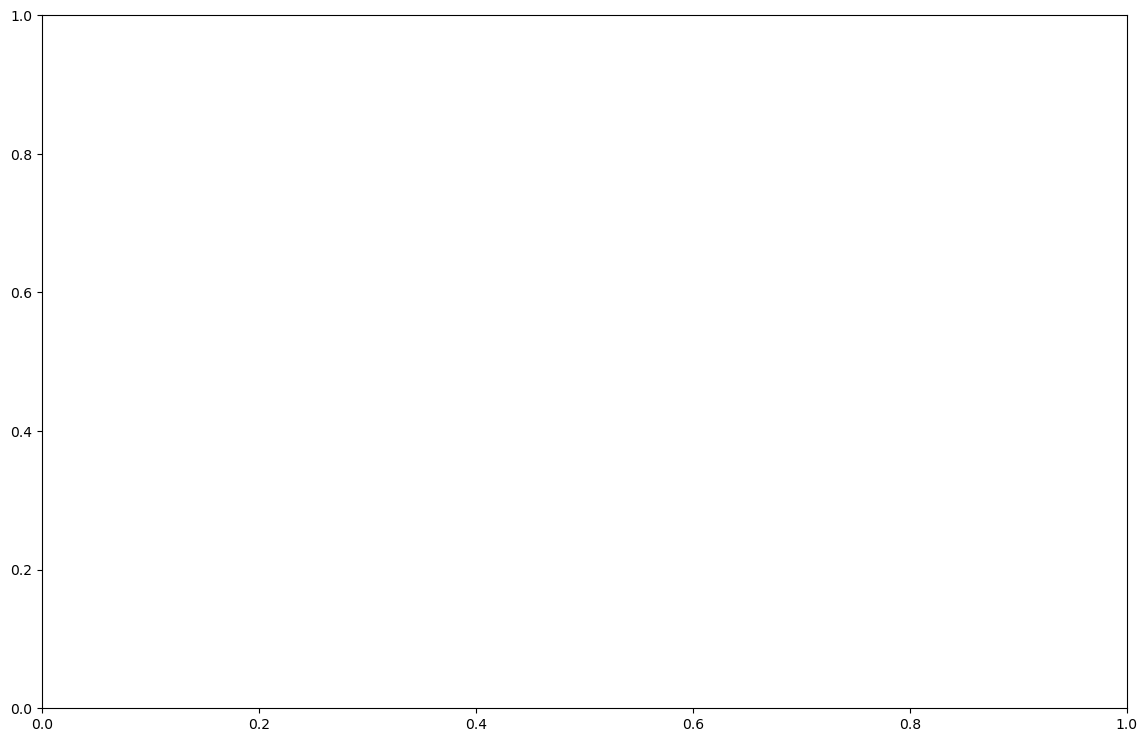


>>> Mostrando MEJOR caso encontrado (Costo optimizado).

LISTA DE MOVIMIENTOS PARA: [1, 5, 30, 20, 10]
--------------------------------------------------
 g(n)=1 | De (5, 0) -> (4, 0)
 g(n)=2 | De (4, 0) -> (3, 0)
 g(n)=3 | De (3, 0) -> (2, 0)
 g(n)=4 | De (2, 0) -> (1, 0)
 g(n)=5 | De (1, 0) -> (1, 1)
 [!] META: Producto 1 recolectado.
 g(n)=6 | De (1, 1) -> (2, 1)
 g(n)=7 | De (2, 1) -> (3, 1)
 [!] META: Producto 5 recolectado.
 g(n)=8 | De (3, 1) -> (4, 1)
 g(n)=9 | De (4, 1) -> (5, 1)
 g(n)=10 | De (5, 1) -> (5, 2)
 g(n)=11 | De (5, 2) -> (5, 3)
 g(n)=12 | De (5, 3) -> (5, 4)
 g(n)=13 | De (5, 4) -> (6, 4)
 g(n)=14 | De (6, 4) -> (7, 4)
 g(n)=15 | De (7, 4) -> (8, 4)
 [!] META: Producto 30 recolectado.
 g(n)=16 | De (8, 4) -> (7, 4)
 g(n)=17 | De (7, 4) -> (6, 4)
 g(n)=18 | De (6, 4) -> (5, 4)
 g(n)=19 | De (5, 4) -> (5, 5)
 g(n)=20 | De (5, 5) -> (5, 6)
 g(n)=21 | De (5, 6) -> (5, 7)
 g(n)=22 | De (5, 7) -> (5, 8)
 g(n)=23 | De (5, 8) -> (5, 9)
 g(n)=24 | De (5, 9) -> (5, 10)
 g(

c:\Users\fduja\anaconda3\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


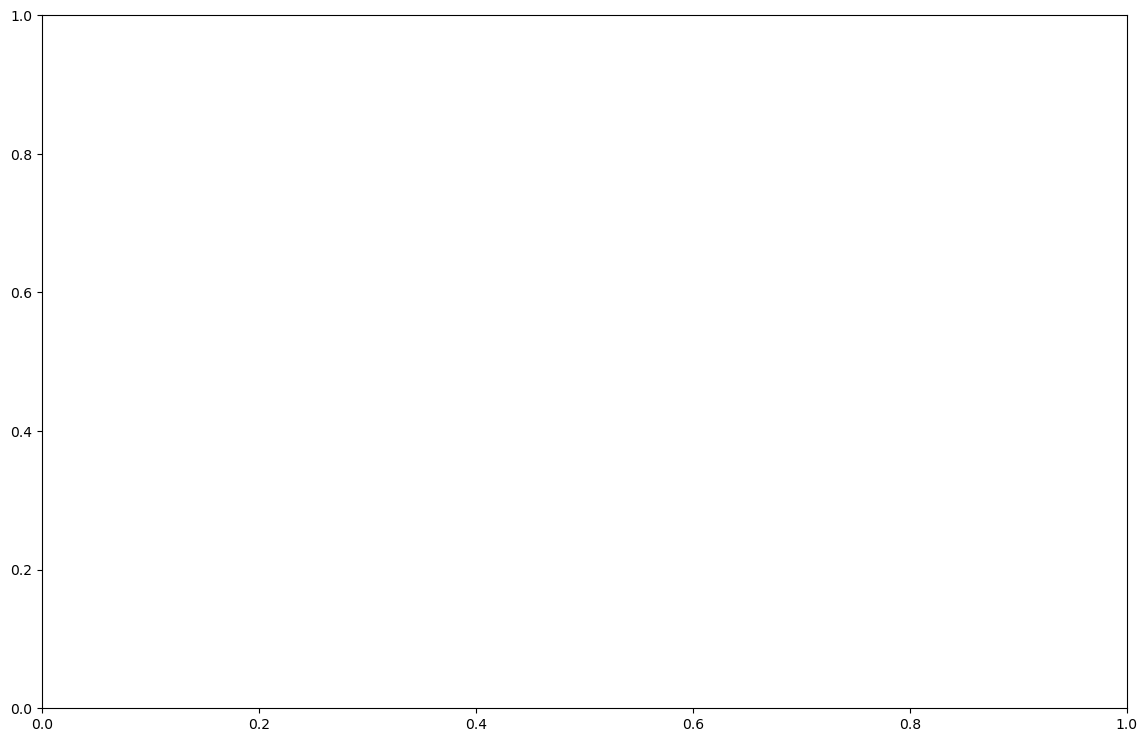


>>> Mostrando PEOR caso encontrado (Costo alto).

LISTA DE MOVIMIENTOS PARA: [30, 1, 20, 5, 10]
--------------------------------------------------
 g(n)=1 | De (5, 0) -> (5, 1)
 g(n)=2 | De (5, 1) -> (5, 2)
 g(n)=3 | De (5, 2) -> (5, 3)
 g(n)=4 | De (5, 3) -> (5, 4)
 g(n)=5 | De (5, 4) -> (6, 4)
 g(n)=6 | De (6, 4) -> (7, 4)
 g(n)=7 | De (7, 4) -> (8, 4)
 [!] META: Producto 30 recolectado.
 g(n)=8 | De (8, 4) -> (7, 4)
 g(n)=9 | De (7, 4) -> (6, 4)
 g(n)=10 | De (6, 4) -> (5, 4)
 g(n)=11 | De (5, 4) -> (5, 3)
 g(n)=12 | De (5, 3) -> (5, 2)
 g(n)=13 | De (5, 2) -> (5, 1)
 g(n)=14 | De (5, 1) -> (4, 1)
 g(n)=15 | De (4, 1) -> (3, 1)
 g(n)=16 | De (3, 1) -> (2, 1)
 g(n)=17 | De (2, 1) -> (1, 1)
 [!] META: Producto 1 recolectado.
 g(n)=18 | De (1, 1) -> (0, 1)
 g(n)=19 | De (0, 1) -> (0, 2)
 g(n)=20 | De (0, 2) -> (0, 3)
 g(n)=21 | De (0, 3) -> (0, 4)
 g(n)=22 | De (0, 4) -> (0, 5)
 g(n)=23 | De (0, 5) -> (0, 6)
 g(n)=24 | De (0, 6) -> (0, 7)
 g(n)=25 | De (0, 7) -> (0, 8)
 g(n)=26 | De (

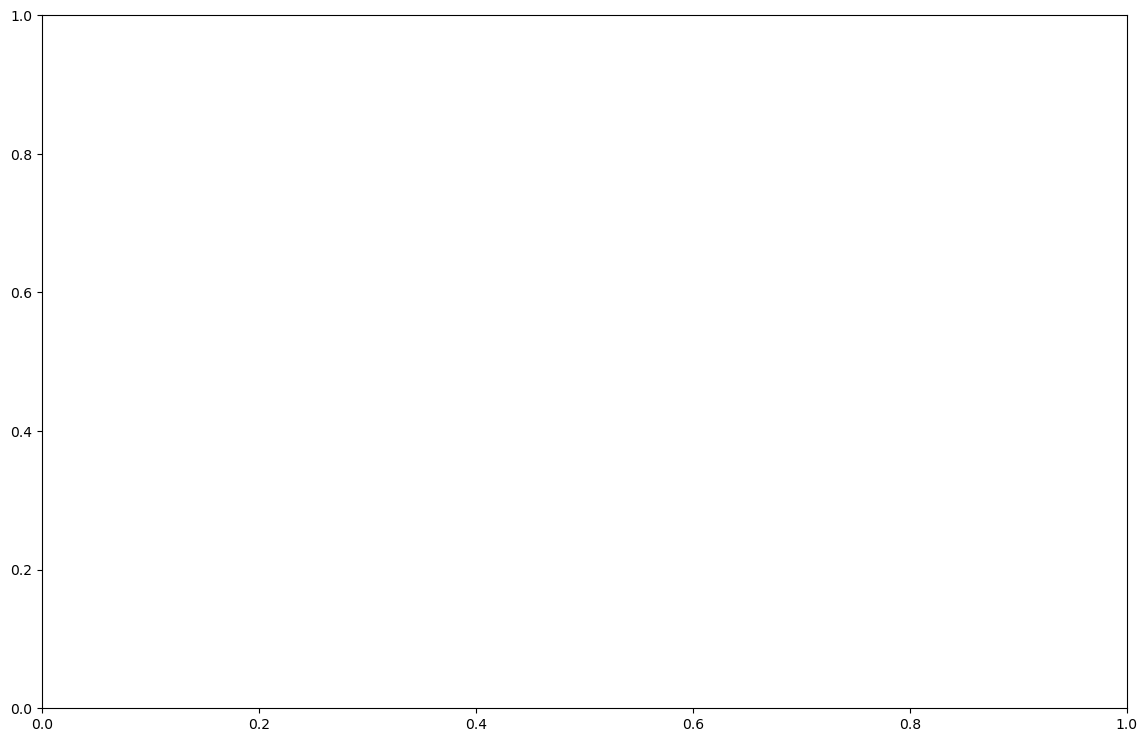


>>> Mostrando MEJOR caso encontrado (Costo optimizado).

LISTA DE MOVIMIENTOS PARA: [1, 5, 30, 20, 10]
--------------------------------------------------
 g(n)=1 | De (5, 0) -> (4, 0)
 g(n)=2 | De (4, 0) -> (3, 0)
 g(n)=3 | De (3, 0) -> (2, 0)
 g(n)=4 | De (2, 0) -> (1, 0)
 g(n)=5 | De (1, 0) -> (1, 1)
 [!] META: Producto 1 recolectado.
 g(n)=6 | De (1, 1) -> (2, 1)
 g(n)=7 | De (2, 1) -> (3, 1)
 [!] META: Producto 5 recolectado.
 g(n)=8 | De (3, 1) -> (4, 1)
 g(n)=9 | De (4, 1) -> (5, 1)
 g(n)=10 | De (5, 1) -> (5, 2)
 g(n)=11 | De (5, 2) -> (5, 3)
 g(n)=12 | De (5, 3) -> (5, 4)
 g(n)=13 | De (5, 4) -> (6, 4)
 g(n)=14 | De (6, 4) -> (7, 4)
 g(n)=15 | De (7, 4) -> (8, 4)
 [!] META: Producto 30 recolectado.
 g(n)=16 | De (8, 4) -> (7, 4)
 g(n)=17 | De (7, 4) -> (6, 4)
 g(n)=18 | De (6, 4) -> (5, 4)
 g(n)=19 | De (5, 4) -> (5, 5)
 g(n)=20 | De (5, 5) -> (5, 6)
 g(n)=21 | De (5, 6) -> (5, 7)
 g(n)=22 | De (5, 7) -> (5, 8)
 g(n)=23 | De (5, 8) -> (5, 9)
 g(n)=24 | De (5, 9) -> (5, 10)
 g(

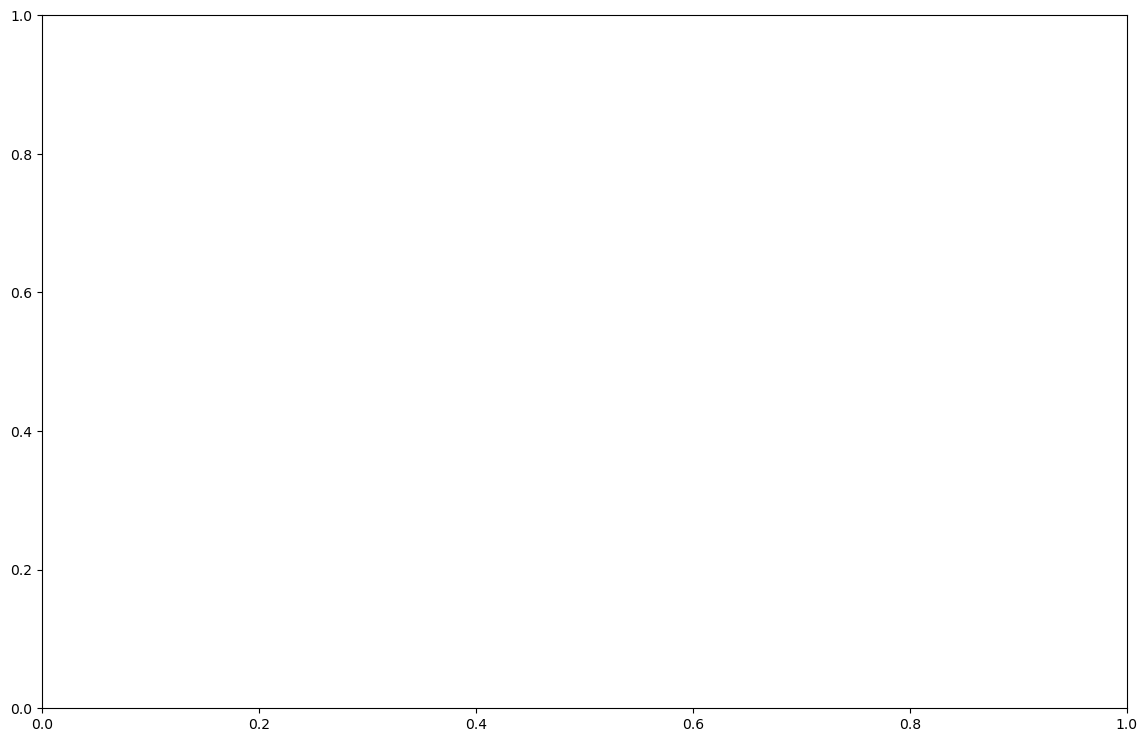


Fin


In [4]:
import heapq
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.animation as animation

# --- 1. CONFIGURACIÓN DEL MAPA (ESPACIO DE ESTADOS) ---
WIDTH, HEIGHT = 15, 11
START_NODE = (5, 0)

# Mapeo de productos a coordenadas (Fila, Columna)
products_map = {}
for r in range(4):
    products_map[r*2 + 1], products_map[r*2 + 2] = (r+1, 2), (r+1, 3)
    products_map[r*2 + 9], products_map[r*2 + 10] = (r+1, 6), (r+1, 7)
    products_map[r*2 + 17], products_map[r*2 + 18] = (r+1, 10), (r+1, 11)
for r in range(4):
    products_map[r*2 + 25], products_map[r*2 + 26] = (r+6, 2), (r+6, 3)
    products_map[r*2 + 33], products_map[r*2 + 34] = (r+6, 6), (r+6, 7)
    products_map[r*2 + 41], products_map[r*2 + 42] = (r+6, 10), (r+6, 11)

shelf_coords = set(products_map.values())

def get_access_point(prod_id):
    r, c = products_map[prod_id]
    return (r, c - 1) if c in [2, 6, 10] else (r, c + 1)

def a_star(start, goal):
    """Algoritmo A* con Heurística Manhattan."""
    oheap = []
    heapq.heappush(oheap, (0, start))
    came_from = {}
    gscore = {start: 0}
    
    while oheap:
        current = heapq.heappop(oheap)[1]
        if current == goal:
            path = []
            while current in came_from:
                path.append(current); current = came_from[current]
            path.append(start)
            return path[::-1]

        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            neighbor = (current[0] + dr, current[1] + dc)
            if 0 <= neighbor[0] < HEIGHT and 0 <= neighbor[1] < WIDTH:
                if neighbor not in shelf_coords:
                    # Costo del arco c(s, a, s') = 1
                    tentative_g = gscore[current] + 1
                    if tentative_g < gscore.get(neighbor, float('inf')):
                        came_from[neighbor] = current
                        gscore[neighbor] = tentative_g
                        # f(n) = g(n) + h(n)
                        f = tentative_g + abs(neighbor[0]-goal[0]) + abs(neighbor[1]-goal[1])
                        heapq.heappush(oheap, (f, neighbor))
    return []

# --- 2. OPTIMIZACIÓN POR REINICIOS ALEATORIOS ---
print("\n" + "="*70)
print(" SISTEMA DE PICKING - OPTIMIZACIÓN Y ANÁLISIS DE COSTOS g(n) ")
print("="*70)

entrada = input("\nUbicación de estanterias(ej: 20,13,30,2,12): ")
try:
    orden_base = [int(x.strip()) for x in entrada.split(',')]
except:
    print("Error en formato."); exit()

intentos = []
colores = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#33FFF3', '#F3FF33', '#FF8333', '#AABBCC', '#FFAA00', '#00AAFF']

print("\nEvaluando 10 variantes de secuencia (Búsqueda Local)...")
for i in range(10):
    test_order = list(orden_base)
    if i > 0: np.random.shuffle(test_order)
    
    costo_acumulado = 0
    pos_temp = START_NODE
    temp_tramos = []
    costos_viajes = []
    
    for p_id in test_order:
        destino = get_access_point(p_id)
        camino = a_star(pos_temp, destino)
        costo_v = len(camino) - 1
        costo_acumulado += costo_v
        temp_tramos.append(camino)
        costos_viajes.append(costo_v)
        pos_temp = destino
    
    regreso_temp = a_star(pos_temp, START_NODE)
    costo_reg = len(regreso_temp) - 1
    costo_acumulado += costo_reg
    temp_tramos.append(regreso_temp)
    costos_viajes.append(costo_reg)
    
    intentos.append({
        'orden': test_order,
        'costo_total': costo_acumulado,
        'tramos': temp_tramos,
        'costos_ind': costos_viajes
    })
    print(f" Intento {i+1}: Costo Total g(n) = {costo_acumulado}")

# Seleccionar los extremos para la comparación
mejor = min(intentos, key=lambda x: x['costo_total'])
peor = max(intentos, key=lambda x: x['costo_total'])

print("\n" + "*"*55)
print(f" GANADOR: Secuencia {mejor['orden']} | Costo: {mejor['costo_total']}")
print(f" DIFERENCIA OPERATIVA: {peor['costo_total'] - mejor['costo_total']} unidades de costo")
print("*"*55)

# --- 3. FUNCIÓN DE ANIMACIÓN CON TERMINOLOGÍA TÉCNICA ---
def animar_intento(intento, titulo_prefijo):
    fig_an, ax_an = plt.subplots(figsize=(14, 9))
    
    order = intento['orden']
    tramos_caminos = intento['tramos']
    costos_ind = intento['costos_ind']
    
    frames = []
    indices_fin_viaje = [] 
    cont = 0
    for i, tramo in enumerate(tramos_caminos):
        for node in tramo[1:]:
            frames.append((node, i))
            cont += 1
        indices_fin_viaje.append(cont)

    history = defaultdict(list)
    recolectados = set()

    def update(frame_idx):
        if frame_idx == 0:
            history.clear()
            recolectados.clear()

        ax_an.clear()
        node, tramo_id = frames[frame_idx]
        history[node].append(tramo_id)
        
        for p_id in order:
            if node == get_access_point(p_id): recolectados.add(p_id)

        # Dibujo de base (Estanterías)
        for (r, c) in shelf_coords:
            ax_an.add_patch(plt.Rectangle((c, r), 1, 1, color='#D3D3D3', ec='black', lw=0.5))
        
        # Dibujo de trayectos (División de casillas compartidas)
        for (r, c), IDs in history.items():
            w = 1.0 / len(IDs)
            for idx, ID_t in enumerate(IDs):
                ax_an.add_patch(plt.Rectangle((c + idx*w, r), w, 1, color=colores[ID_t%len(colores)], alpha=0.7))
        
        # Productos
        for p_id in order:
            r, c = products_map[p_id]
            color_p = '#2ECC71' if p_id in recolectados else 'red'
            ax_an.add_patch(plt.Rectangle((c, r), 1, 1, color=color_p, ec='black', lw=1.5, zorder=10))
            ax_an.text(c+0.5, r+0.5, str(p_id), color='white', ha='center', va='center', fontweight='bold', zorder=11)

        # Inicio C y Agente
        ax_an.add_patch(plt.Rectangle((START_NODE[1], START_NODE[0]), 1, 1, color='yellow', ec='black', zorder=12))
        ax_an.plot(node[1]+0.5, node[0]+0.5, 'ko', markersize=12, zorder=15)
        
        ax_an.set_xlim(0, WIDTH); ax_an.set_ylim(HEIGHT, 0); ax_an.set_aspect('equal')
        ax_an.set_title(f"{titulo_prefijo}\nEstado Actual: {node} | Paso: {frame_idx + 1}")

        # PANEL DE COSTOS g(n)
        texto_panel = "ANÁLISIS DE COSTOS g(n)\n" + "-"*22 + "\n"
        acumulado_vis = 0
        for i in range(len(costos_ind)):
            lbl = f"Viaje {i+1}" if i < len(order) else "Regreso"
            if frame_idx + 1 >= indices_fin_viaje[i]:
                texto_panel += f"{lbl}: cost={costos_ind[i]}\n"
                acumulado_vis += costos_ind[i]
            elif i == tramo_id:
                texto_panel += f"{lbl}: calculando...\n"
                break
        
        texto_panel += "-"*22 + f"\nCOSTO TOTAL g(n): {acumulado_vis}"
        ax_an.text(WIDTH + 0.5, 0, texto_panel, fontsize=10, family='monospace',
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ani = animation.FuncAnimation(fig_an, update, frames=len(frames), interval=100, repeat=True)
    plt.show()

# --- 4. LISTADO DE MOVIMIENTOS Y BUCLE DE ANIMACIÓN ---
def imprimir_lista(intento):
    print(f"\nLISTA DE MOVIMIENTOS PARA: {intento['orden']}")
    print("-" * 50)
    g_n = 0
    for i, tramo in enumerate(intento['tramos']):
        for k in range(len(tramo)-1):
            g_n += 1
            print(f" g(n)={g_n} | De {tramo[k]} -> {tramo[k+1]}")
        if i < len(intento['orden']):
            print(f" [!] META: Producto {intento['orden'][i]} recolectado.")
    print("-" * 50)

while True:
    print("\n>>> Mostrando PEOR caso encontrado (Costo alto).")
    imprimir_lista(peor)
    animar_intento(peor, "ANIMACIÓN 1: CASO SUBÓPTIMO (Mínimo Local)")

    print("\n>>> Mostrando MEJOR caso encontrado (Costo optimizado).")
    imprimir_lista(mejor)
    animar_intento(mejor, "ANIMACIÓN 2: CASO ÓPTIMO (Random Restart A*)")
    
    op = input("\n¿Repetir videos? (s/n): ").lower()
    if op != 's': break

print("\nFin")

## Algoritmos Genéticos

Dado el histórico de órdenes pedidas (que puede encontrar en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T)), implemente un algoritmo genético para optimizar la ubicación de los productos en el almacén, de manera que **los productos pedidos con más frecuencia se ubiquen más cerca de la estación de carga**. Considere que la operación de picking comienza y termina en la estación de carga.

Una vez que el algoritmo determine una configuración de productos, realize un diagrama del almacén con la nueva configuración de productos que tenga un mapa de calor para graficar la frecuencia con la que cada producto es solicitado.

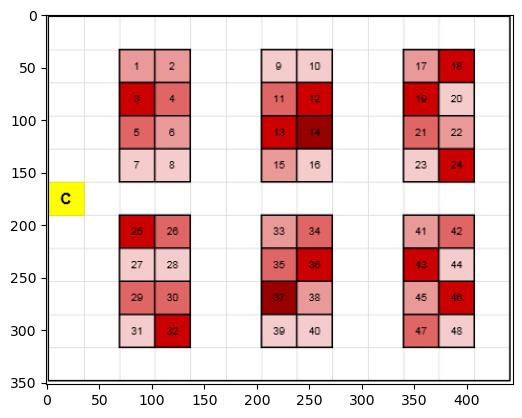

In [ ]:
image = io.imread("https://drive.google.com/uc?export=view&id=1PHW426bY8Q31gBqEsvE5FFzhGnTuvjox")
plt.imshow(image)
plt.show()

Calculando rutas con A*... (esto tomará un segundo)
Iniciando Algoritmo Genético...
Generación 0 | Mejor costo actual: 5686
Generación 20 | Mejor costo actual: 5336
Generación 40 | Mejor costo actual: 5110
Generación 60 | Mejor costo actual: 5034
Generación 80 | Mejor costo actual: 4940
Generación 100 | Mejor costo actual: 4892
Generación 120 | Mejor costo actual: 4864
Generación 140 | Mejor costo actual: 4830
Generación 160 | Mejor costo actual: 4820
Generación 180 | Mejor costo actual: 4804

Optimización finalizada. Mejor costo global encontrado: 4792


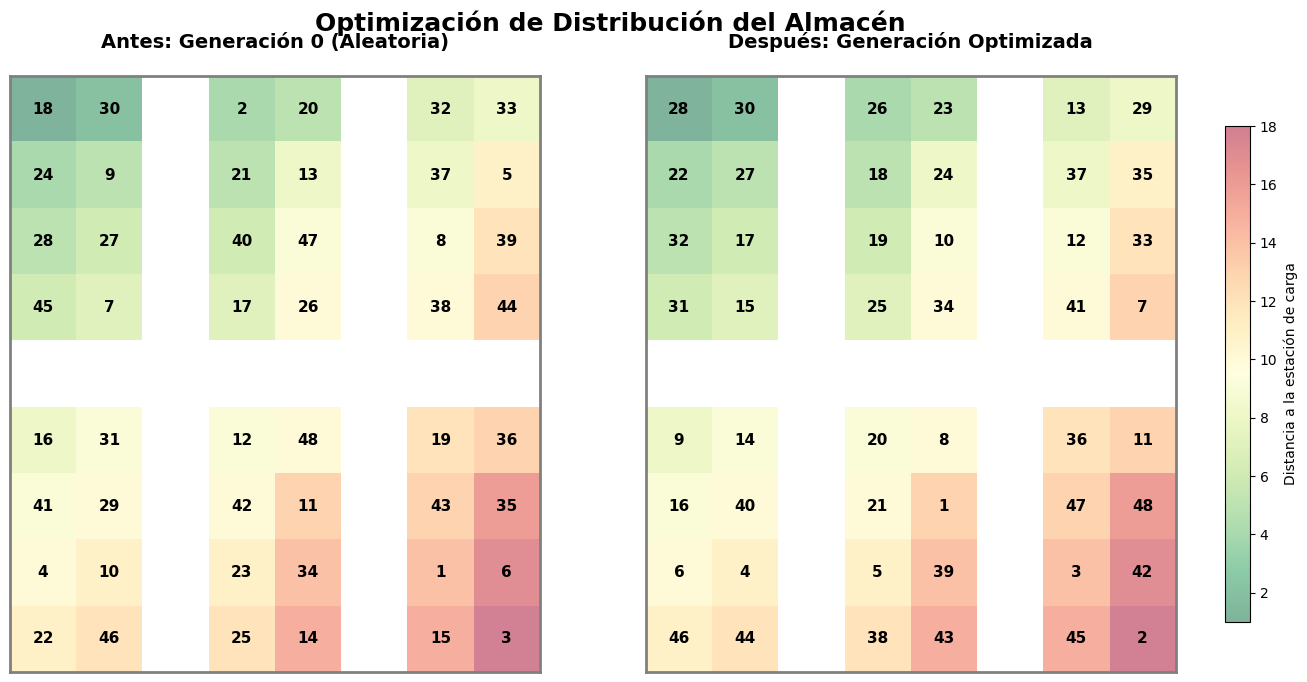

In [ ]:
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
import heapq
# =============================================================================
# 1. CONFIGURACIÓN Y PRE-CÁLCULOS
# =============================================================================
NUM_PRODUCTOS = 48
TAMANO_POBLACION = 100
GENERACIONES = 200
TASA_ELITISMO = 0.2  # El 20% de los mejores pasan directamente
TASA_MUTACION = 0.8  # Probabilidad de que un individuo sufra mutación

# Simulamos las posiciones de los 48 estantes en un grid de 6x8
# MODIFICADO: Ahora es 6 columnas (x) por 8 filas (y) para coincidir con tu diseño
posiciones_estantes = [(x, y) for x in range(6) for y in range(8)]
estacion_carga = (0, -1)



# --- INICIO DEL CÁLCULO CON A* ---
# 1. Función para mapear la matriz lógica (6x8) a la matriz física con pasillos (8x9)
def coord_fisica(x, y):
    vis_x = x if x < 2 else (x + 1 if x < 4 else x + 2)
    vis_y = y if y < 4 else y + 1
    return vis_x, vis_y

# 2. Definimos todos los estantes como "obstáculos" para que el montacargas no los atraviese
obstaculos = set(coord_fisica(x, y) for x, y in posiciones_estantes)

# 3. Implementación del algoritmo A*
# 3. Implementación del algoritmo A*
def a_star(inicio, destino):
    movimientos = [(0, 1), (0, -1), (1, 0), (-1, 0)] # Arriba, Abajo, Derecha, Izquierda
    open_set = []
    heapq.heappush(open_set, (0, 0, inicio)) # (costo_f, costo_g, nodo_actual)
    g_costs = {inicio: 0}
    
    while open_set:
        _, costo_g, actual = heapq.heappop(open_set)
        
        if actual == destino:
            return costo_g # Llegamos al estante objetivo
            
        for dx, dy in movimientos:
            vecino = (actual[0] + dx, actual[1] + dy)
            
            # --- ÚNICA LÍNEA MODIFICADA ---
            # Límites ampliados (-1 a 8 en X, -1 a 9 en Y) para crear un pasillo que rodee todo
            if not (-1 <= vecino[0] <= 8 and -1 <= vecino[1] <= 9):
                continue
                
            # Si el vecino es un estante (obstáculo) y no es nuestro destino final, no podemos pasar
            if vecino in obstaculos and vecino != destino:
                continue
                
            nuevo_costo_g = costo_g + 1
            
            if vecino not in g_costs or nuevo_costo_g < g_costs[vecino]:
                g_costs[vecino] = nuevo_costo_g
                # Heurística: Distancia Manhattan básica desde el vecino al destino
                heuristica = abs(vecino[0] - destino[0]) + abs(vecino[1] - destino[1])
                costo_f = nuevo_costo_g + heuristica
                heapq.heappush(open_set, (costo_f, nuevo_costo_g, vecino))
                
    return float('inf') # Por seguridad, si no encuentra ruta

# 4. Ejecutamos A* para pre-calcular las rutas reales
distancias_precalculadas = {}
inicio_fisico = estacion_carga # (0, -1)

print("Calculando rutas con A*... (esto tomará un segundo)")
for i, pos in enumerate(posiciones_estantes):
    destino_fisico = coord_fisica(pos[0], pos[1])
    # A* encuentra la ruta esquivando los demás estantes
    distancias_precalculadas[i] = a_star(inicio_fisico, destino_fisico)
# --- FIN DEL CÁLCULO CON A* ---

# =============================================================================
# 2. CARGA DE ÓRDENES
# =============================================================================
def cargar_ordenes(ruta_archivo):
    """Carga las órdenes desde el archivo CSV."""
    ordenes = []
    try:
        with open(ruta_archivo, 'r') as file:
            reader = csv.reader(file)
            for row in reader:
                # Convertimos cada ID de producto a entero. Restamos 1 para usar índices base 0
                orden = [int(p) - 1 for p in row if p.strip()]
                ordenes.append(orden)
    except FileNotFoundError:
        print("Archivo de órdenes no encontrado. Generando órdenes aleatorias para demostración.")
        ordenes = [[random.randint(0, 47) for _ in range(5)] for _ in range(20)]
    return ordenes

ordenes = cargar_ordenes('ordenes.csv')

# =============================================================================
# 3. FUNCIONES DEL ALGORITMO GENÉTICO
# =============================================================================

def crear_individuo():
    """Crea una permutación aleatoria de los 48 productos."""
    individuo = list(range(NUM_PRODUCTOS))
    random.shuffle(individuo)
    return individuo

def calcular_costo_ruta(individuo, ordenes):
    """
    Calcula la distancia total recorrida para satisfacer todas las órdenes.
    El picking comienza en la estación de carga, va a cada producto y vuelve.
    """
    costo_total = 0
    for orden in ordenes:
        # Para simplificar: el montacargas va desde la carga hasta el producto y vuelve.
        # (Si el montacargas lleva múltiples productos en un solo viaje, se sumaría la 
        # distancia entre estantes, lo cual es otra variante del problema).
        for producto in orden:
            # Encontramos en qué estante (índice) está el producto en el mapa actual (individuo)
            indice_estante = individuo.index(producto)
            # El viaje es ida y vuelta
            costo_total += distancias_precalculadas[indice_estante] * 2
    return costo_total

def evaluar_poblacion(poblacion, ordenes):
    """Evalúa a toda la población y devuelve una lista de tuplas (individuo, fitness)."""
    evaluaciones = []
    for ind in poblacion:
        costo = calcular_costo_ruta(ind, ordenes)
        # El fitness es inversamente proporcional al costo. Evitamos división por cero.
        fitness = 1.0 / (costo + 1e-6)
        evaluaciones.append((ind, fitness, costo))
    # Ordenamos de mayor a menor fitness (menor costo)
    evaluaciones.sort(key=lambda x: x[1], reverse=True)
    return evaluaciones

def seleccion_ruleta(evaluaciones):
    """Selecciona un individuo basado en su probabilidad (fitness normalizado)."""
    suma_fitness = sum([eval[1] for eval in evaluaciones])
    limite = random.uniform(0, suma_fitness)
    acumulado = 0
    for eval in evaluaciones:
        acumulado += eval[1]
        if acumulado >= limite:
            return eval[0]
    return evaluaciones[-1][0]

def mutacion_intercambio(individuo):
    """Intercambia dos productos de lugar de forma aleatoria en el almacén."""
    if random.random() < TASA_MUTACION:
        idx1, idx2 = random.sample(range(NUM_PRODUCTOS), 2)
        individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
    return individuo

# =============================================================================
# 4. BUCLE PRINCIPAL DEL ALGORITMO
# =============================================================================
def ejecutar_algoritmo_genetico():
    print("Iniciando Algoritmo Genético...")
    # 1. Inicializar población
    poblacion = [crear_individuo() for _ in range(TAMANO_POBLACION)]
    mejores_costos_historicos = []
    mejor_solucion_global = None
    mejor_costo_global = float('inf')

    # MODIFICADO: Guardamos la mejor distribución de la Generación 0 para comparar luego
    evaluaciones_iniciales = evaluar_poblacion(poblacion, ordenes)
    mejor_solucion_inicial = list(evaluaciones_iniciales[0][0])

    for generacion in range(GENERACIONES):
        # 2. Evaluar
        evaluaciones = evaluar_poblacion(poblacion, ordenes)
        mejor_actual, _, costo_actual = evaluaciones[0]
        mejores_costos_historicos.append(costo_actual)
        
        if costo_actual < mejor_costo_global:
            mejor_costo_global = costo_actual
            mejor_solucion_global = list(mejor_actual)
            
        # 3. Elitismo
        num_elites = int(TAMANO_POBLACION * TASA_ELITISMO)
        nueva_poblacion = [list(ind) for ind, fit, cost in evaluaciones[:num_elites]]
        
        # 4. Generar el resto de la población (Selección + Mutación)
        while len(nueva_poblacion) < TAMANO_POBLACION:
            # Seleccionamos un padre por ruleta
            padre = seleccion_ruleta(evaluaciones)
            # Creamos un hijo copiando al padre
            hijo = list(padre)
            # Mutamos al hijo
            hijo = mutacion_intercambio(hijo)
            nueva_poblacion.append(hijo)
            
        poblacion = nueva_poblacion
        
        if generacion % 20 == 0:
            print(f"Generación {generacion} | Mejor costo actual: {costo_actual}")
            
    print(f"\nOptimización finalizada. Mejor costo global encontrado: {mejor_costo_global}")
    # MODIFICADO: Ahora también devolvemos la solución inicial
    return mejor_solucion_global, mejores_costos_historicos, mejor_solucion_inicial

mejor_distribucion, historial, distribucion_inicial = ejecutar_algoritmo_genetico()

# =============================================================================
# 5. VISUALIZACIÓN DE RESULTADOS
# =============================================================================
def visualizar_almacen_comparativo(dist_inicial, dist_final):
    """Genera una imagen comparativa (Antes vs Después) con pasillos en blanco."""
    
    # Mapeo para simular pasillos visualmente. 
    # Convertimos la matriz de 6x8 a una de 8x9 para dejar celdas en blanco.
    filas_vis = 9  # 8 filas de estantes + 1 pasillo horizontal al medio
    cols_vis = 8   # 6 columnas de estantes + 2 pasillos verticales
    
    def obtener_coord_visual(x, y):
        # Crea pasillos verticales después de las columnas 1 y 3
        vis_x = x if x < 2 else (x + 1 if x < 4 else x + 2)
        # Crea un pasillo horizontal después de la fila 3
        vis_y = y if y < 4 else y + 1
        return vis_x, vis_y

    # Matrices llenas de "NaN" (Not a Number) para que Matplotlib las deje en blanco
    matriz_ids_ini = np.full((filas_vis, cols_vis), np.nan)
    matriz_ids_fin = np.full((filas_vis, cols_vis), np.nan)
    matriz_dist_vis = np.full((filas_vis, cols_vis), np.nan)

    # Llenamos las matrices con los datos reales saltando los pasillos
    for i, pos in enumerate(posiciones_estantes):
        vx, vy = obtener_coord_visual(pos[0], pos[1])
        matriz_ids_ini[vy, vx] = dist_inicial[i] + 1
        matriz_ids_fin[vy, vx] = dist_final[i] + 1
        matriz_dist_vis[vy, vx] = distancias_precalculadas[i]

    # Configuramos la figura con 2 subgráficos
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Configuramos el mapa de color. set_bad('white') hace que los NaN sean blancos.
    cmap = plt.cm.RdYlGn_r
    cmap.set_bad(color='white')

    # --- Gráfico 1: Inicial ---
    cax1 = axes[0].matshow(matriz_dist_vis, cmap=cmap, alpha=0.5)
    axes[0].set_title('Antes: Generación 0 (Aleatoria)', pad=20, fontsize=14, fontweight='bold')
    for i, pos in enumerate(posiciones_estantes):
        vx, vy = obtener_coord_visual(pos[0], pos[1])
        axes[0].text(vx, vy, str(int(matriz_ids_ini[vy, vx])), 
                     va='center', ha='center', fontweight='bold', fontsize=11)

    # --- Gráfico 2: Final ---
    cax2 = axes[1].matshow(matriz_dist_vis, cmap=cmap, alpha=0.5)
    axes[1].set_title('Después: Generación Optimizada', pad=20, fontsize=14, fontweight='bold')
    for i, pos in enumerate(posiciones_estantes):
        vx, vy = obtener_coord_visual(pos[0], pos[1])
        axes[1].text(vx, vy, str(int(matriz_ids_fin[vy, vx])), 
                     va='center', ha='center', fontweight='bold', fontsize=11)

    # Limpieza visual para que parezca un plano
    for ax in axes:
        ax.set_xticks([]) # Oculta los números de los ejes X e Y
        ax.set_yticks([])
        # Bordes para enmarcar el almacén
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(2)

    # Barra de color compartida
    fig.colorbar(cax2, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Distancia a la estación de carga')
    
    plt.suptitle('Optimización de Distribución del Almacén', fontsize=18, fontweight='bold', y=0.95)
    plt.show()

# MODIFICADO: Llamamos a la nueva función pasándole ambas distribuciones
visualizar_almacen_comparativo(distribucion_inicial, mejor_distribucion)

![Optimización de almacén](Optimización%20de%20almacén.png)